## 1.4 Calculate pressure from FI data using DiadFit
<div style="background-color:#eef8fa; border-left:4px solid #24bdff; padding:10px; border-radius:4px;">
<b> 🧮 &nbsp; DiadFit </b> is an open-source python3 tool for fitting Raman spectra.

More information on DiadFit can be found at https://diadfit.readthedocs.io/en/latest/

</div>

## 1.4.1 Import packages and note versions

In [1]:
# Packages that we will use in our code always get imported before we need them.
# This is canonically done at the top of a script.
# ⚠️ Note that this can take a few seconds if it's the first time you're importing these libraries.

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import DiadFit as pf

import os
os.makedirs("output", exist_ok=True) # creates the output folder

When reporting calculations in manuscripts, it's important to know which version of the Python package the results you are showing used - so we can output those below. This notebook was created using DiadFit: 1.0.23.

In [2]:
print(
    f"\nDiadFit: {pf.__version__}"
    )


DiadFit: 1.0.23


## 1.4.2 Import data

We're using FI data from DeVitre & Wieser (2024):

In [3]:
df_FI = pd.read_excel("data/Kilauea_MI_FI_MG_data.xlsx", sheet_name='FI_Data') # creates a DataFrame of just data in the FI_Data sheet

First, let's look at the FI density:

Text(0, 0.5, '# of analyses')

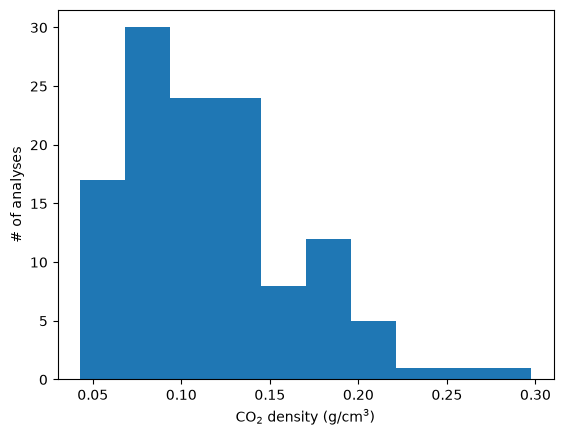

In [4]:
# create a histogram of CO2 density
plt.hist(df_FI['CO2 density (g/cm3)'])

# label axes
plt.xlabel('CO$_2$ density (g/cm$^3$)')
plt.ylabel('# of analyses')

## 1.4.3 Explore options

DiadFit has various equations of state (EOS) built in to convert between CO<sub>2</sub> density and pressure - these options are shown below:

In [5]:
help(pf.calculate_P_for_rho_T)

Help on function calculate_P_for_rho_T in module DiadFit.CO2_EOS:

calculate_P_for_rho_T(CO2_dens_gcm3, T_K, EOS='SW96', Sample_ID=None)
    This function calculates P in kbar for a specified CO2 density in g/cm3, a known T (in K), and a specified EOS

    Parameters
    ---------------------
    CO2_dens_gcm3: int, float, pd.Series, np.array
        CO2 density in g/cm3

    T_K: int, float, pd.Series, np.array
        Temperature in Kelvin

    EOS: str
        'SW96' for Span and Wanger (1996),  'SP94' for Sterner and Pitzer (1994),
        or  'DZ06' for Pure CO2 from Duan and Zhang (2006)

    Sample_ID: str, pd.Series
        Sample ID to be appended onto output dataframe

    Returns
    --------------------
    pd.DataFrame
        Pressure in kbar, MPa and input parameters



## 1.4.4 Run calculations

Let's play around with how an EOS works - try changing the temperature in the cell below and see how much it matters

In [6]:
# runs calculation
P_SP94=pf.calculate_P_for_rho_T(CO2_dens_gcm3=0.1, 
                                T_K=1300+273.15, # << try changing this number
                                EOS='SP94') 
P_SP94 # displays result

,P_kbar,P_MPa,T_K,CO2_dens_gcm3
0,0.318014,31.801396,1573.15,0.1


We can calculate P for all the FI data in our spreadsheet using the EOS for Sterner and Pitzer (1994) - the temperatures in this file were calculated from Fo content of the host olivine

In [7]:
# run the calculation
results_P_df=pf.calculate_P_for_rho_T(CO2_dens_gcm3=df_FI['CO2 density (g/cm3)'], T_K=df_FI['Temperature (K)'], EOS='SP94')

# save the results
results_P_df.to_csv("output/results_P_df.csv")

# uncomment the line below to interrogate the resulting dataframe
#results_P_df

## 1.4.5 Plotting

And we can plot a histogram of the pressures

In [10]:
# if you haven't run this Exercise, you can grab the "answer key" files from here:
#results_P_df = pd.read_csv("files/results_P_df.csv")

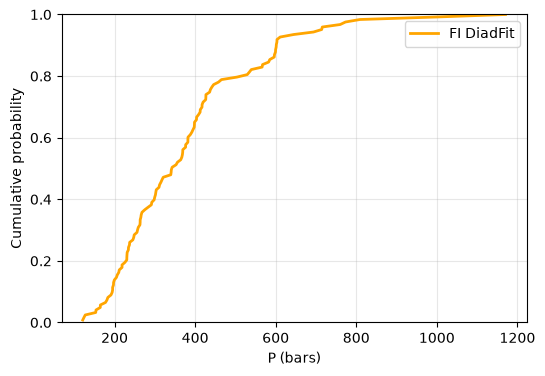

In [9]:
fig, ax = plt.subplots(figsize=(6, 4)) # single panel figure

# clean the datasets for plotting - DiadFit will be in orange
datasets = [
    ((results_P_df['P_kbar'] * 1000).dropna(), 'FI DiadFit', 'orange')
]

# plot as cumulative probability
for data, label, color in datasets:
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, lw=2, label=label, color=color)

# label axes
ax.set_xlabel('P (bars)')
ax.set_ylabel('Cumulative probability')

ax.set_ylim(0, 1) # set axes range
ax.legend() # add legend
ax.grid(alpha=0.3) # add grid